In [1]:
import numpy as np
import pandas as pd
from astropy import units as u
from scipy import optimize
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter("error", optimize.OptimizeWarning)

#Figure creation
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import Normalize, LogNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.legend_handler import HandlerTuple
from matplotlib.markers import MarkerStyle
from matplotlib.transforms import Affine2D
import corner

def fig_size(width_pt, fraction=1.0, ratio=0.6180):
    fig_w = width_pt * fraction / 72.27
    fig_h = fig_w * ratio
    return fig_w, fig_h

#Set seed for reproduceability
np.random.seed(42)

In [2]:
PATH_TO_CATALOGUES = "./" #Variable for an arbitrary pathing

#Load in the catalogues, apply the Mieske+08 correction for the UCDs and exclude the Taylor+10 entries
mw_df   = pd.read_csv(PATH_TO_CATALOGUES+"MW_GC_Catalogue.csv")
M31_df  = pd.read_csv(PATH_TO_CATALOGUES+"M31_GC_Catalogue.csv")
UCD_df  = pd.read_csv(PATH_TO_CATALOGUES+"UCD_Catalogue.csv")

UCD_df['sigma_global'] = UCD_df['sigma'].values / np.where(UCD_df['Central?'] == 'N', 1, 1.23)
UCD_df = UCD_df.loc[(UCD_df['Environment'] != 'NGC 5128')]

## Figure 1

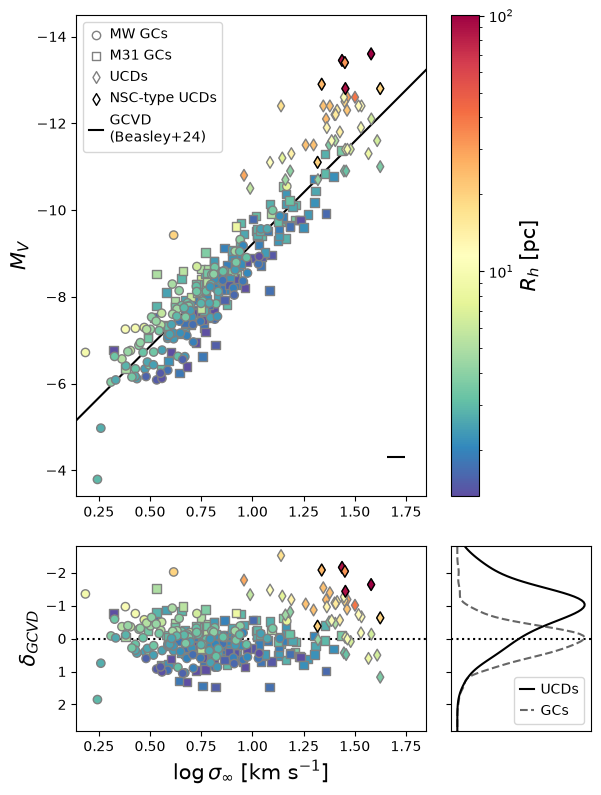

In [3]:
figsize =  fig_size(480, ratio = 1.4)
scale = figsize[0] / (480.0 / 72.27)
base_pt = 10 
fig = plt.figure(figsize=figsize)

#Setup of the subplot grid
gs = gridspec.GridSpec(2, 2, width_ratios=[5, 2], height_ratios = [3,1.15], hspace=0.15, wspace=0.1)

ax_ul = fig.add_subplot(gs[0, 0])
ax_ll = fig.add_subplot(gs[1, 0], sharex = ax_ul)
ax_lr = fig.add_subplot(gs[1, 1], sharey = ax_ll)
gs_ur = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 1],
                                width_ratios=[1, 4], wspace=0)
cax = fig.add_subplot(gs_ur[0, 0])  
ax_ur = fig.add_subplot(gs_ur[0, 1])
ax_ur.set_visible(False)

#Defining the colours for the plots
norm = LogNorm(vmin = min(mw_df['Re']), 
                 vmax = max(UCD_df['Re']))
c_map = 'Spectral_r' #Colour map
edge_c = 'gray' #Edge colour

#Plotting the data
im = ax_ul.scatter(np.log10(mw_df['sigma_global']), mw_df['MV'], c = mw_df['Re'].astype(float), 
                 norm = norm, cmap = c_map, edgecolor = edge_c, zorder = 2)
ax_ul.scatter(0,0,c = 'white', label = 'MW GCs', edgecolor = edge_c) #To add them to the legend without colour

ax_ul.scatter(np.log10(M31_df['sigma_global']), M31_df['MV'],c = M31_df['Re'], 
           norm = norm, cmap = c_map, edgecolor = edge_c, zorder = 1, marker = 's')
ax_ul.scatter(0,0,c = 'white', label = 'M31 GCs', edgecolor = edge_c, marker = 's') #To add them to the legend without colour

ax_ul.scatter(np.log10(UCD_df['sigma_global']), UCD_df['VMAG'], c = UCD_df['Re'], 
           marker = 'd', cmap = c_map, norm = norm, edgecolor = edge_c, zorder = 3)
ax_ul.scatter(0,0,c = 'white', label = 'UCDs', edgecolor = edge_c, marker = 'd') #To add them to the legend without colour

UCD_df_NSC = UCD_df.iloc[[13,18,27,26,38,42,31]] #Manually select the NSC-type UCDs from the catalogue
ax_ul.scatter(np.log10(UCD_df_NSC['sigma_global']), UCD_df_NSC['VMAG'], c = UCD_df_NSC['Re'], 
           marker = 'd', cmap = c_map, norm = norm, edgecolor = 'black', zorder = 3)
ax_ul.scatter(0,0,c = 'white', label = 'NSC-type UCDs', edgecolor = 'black', marker = 'd')

ax_ll.set_xlabel(r'$\log\sigma_\infty$ [km s$^{-1}$]', fontsize = 15)
ax_ul.set_ylabel('$M_V$', fontsize = 15)
ax_ul.invert_yaxis()

#Plot the Beasley+24 fiducial GCVD
x_range = np.linspace(.1,2, 100)
ax_ul.plot(x_range, -4.49 - 4.73*x_range, c = 'black', label = 'GCVD\n(Beasley+24)', zorder = 0)

#The Mieske+08 difference between global and central
ax_ul.errorbar(1.7,-4.3, xerr = np.log10(1.23)/2, c = 'black')

cbar = fig.colorbar(im, cax = cax, cmap = c_map)
cbar.set_label(label = '$R_{h}$ [pc]', fontsize = 15)
ax_ul.set_xlim(.14,1.85)
ax_ul.set_ylim(-3.4,-14.5)
ax_ul.legend(loc = 'upper left', fontsize=base_pt * scale, handlelength=1., handletextpad=0.5)
#--------------------------------------------
#Calculate and plot the residuals for each of the datasets with the GCVD
MW_residuals = mw_df['MV'] - (-4.49 - 4.73*np.log10(mw_df['sigma_global']))
M31_residuals = M31_df['MV'] - (-4.49 - 4.73*np.log10(M31_df['sigma_global']))
UCD_residuals = UCD_df['VMAG'] - (-4.49 - 4.73*np.log10(UCD_df['sigma_global']))

ax_ll.scatter(np.log10(mw_df['sigma_global']), MW_residuals, c = mw_df['Re'].astype(float), 
                 norm = norm, cmap = c_map, edgecolor = edge_c, zorder = 2)

ax_ll.scatter(np.log10(M31_df['sigma_global']), M31_residuals,c = M31_df['Re'], 
           norm = norm, cmap = c_map, edgecolor = edge_c, zorder = 1, marker = 's')

ax_ll.scatter(np.log10(UCD_df['sigma_global']), UCD_residuals, c = UCD_df['Re'], 
           marker = 'd', cmap = c_map, norm = norm, edgecolor = edge_c, zorder = 3)

UCD_residuals_NSC = UCD_df_NSC['VMAG'] - (-4.49 - 4.73*np.log10(UCD_df_NSC['sigma_global']))
ax_ll.scatter(np.log10(UCD_df_NSC['sigma_global']), UCD_residuals_NSC, c = UCD_df_NSC['Re'], 
           marker = 'd', cmap = c_map, norm = norm, edgecolor = 'black', zorder = 3)

ax_ll.set_yticks([-2,-1,0,1,2])
ax_ll.set_ylim(-2.8,2.8)
ax_ll.invert_yaxis()
ax_ll.axhline(0,0,1, c = 'black', linestyle = 'dotted', zorder = 0)
ax_ll.set_ylabel(r'$\delta_{GCVD}$', fontsize = 15)

#Run KDE for the distributions of the residuals
GC_kde = gaussian_kde(np.concatenate([MW_residuals, M31_residuals]))
UCD_kde = gaussian_kde(UCD_residuals)
y_range = np.linspace(-2.8,2.8,100)

ax_lr.plot(UCD_kde(y_range)/UCD_kde(y_range).max(), y_range, c = 'black', label = 'UCDs', zorder = 2)
ax_lr.plot(GC_kde(y_range)/GC_kde(y_range).max(), y_range, c = 'black', linestyle = 'dashed', alpha = 0.6, label = 'GCs', zorder = 1)

ax_lr.tick_params(axis = 'y', labelleft = False)
ax_lr.tick_params(axis = 'x', bottom = False, labelbottom = False)
ax_lr.axhline(0,0,1, c = 'black', linestyle = 'dotted', zorder = 0)
ax_lr.legend(handlelength=1, handletextpad=0.5)
fig.canvas.draw()
plt.show()

## Residuals

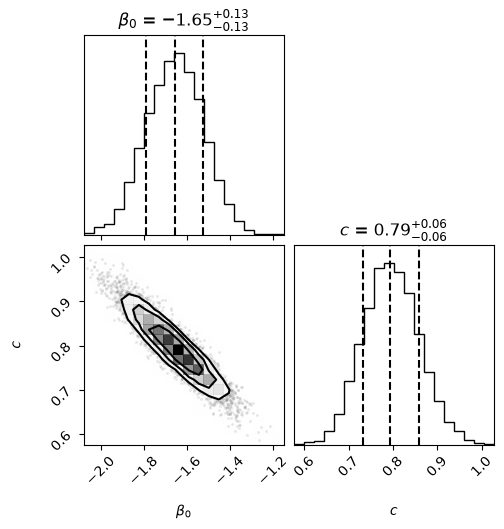

In [4]:
#Bring the MW and M31 residuals together
ydata_gcs = np.concatenate([MW_residuals.values, M31_residuals.values]).reshape(-1,1)
xdata_gcs = np.concatenate([np.log10(mw_df['Re']), np.log10(M31_df['Re'])]).reshape(-1,1)

#Initial linear regression
mod = LinearRegression().fit(xdata_gcs, ydata_gcs)
ini_res = ydata_gcs - mod.predict(xdata_gcs)

#(Wild) bootstrapping; # = 5000
boot_list = []
for _ in range(5000):
    bootstrap = ini_res.flatten()*(2*np.random.randint(2, size = ini_res.size) - 1)
    y_alt = mod.predict(xdata_gcs).flatten() + bootstrap

    mod_cycle = LinearRegression().fit(xdata_gcs, y_alt)
    boot_list.append([mod_cycle.coef_[0], mod_cycle.intercept_])

arr = np.array(boot_list)

#Plot the resulting distributions
corner.corner(arr,
              labels=[r"$\beta_0$",r"$c$"],
              quantiles=[0.16, 0.5, 0.84],
              show_titles=True,
              title_kwargs={"fontsize": 12})
plt.show()

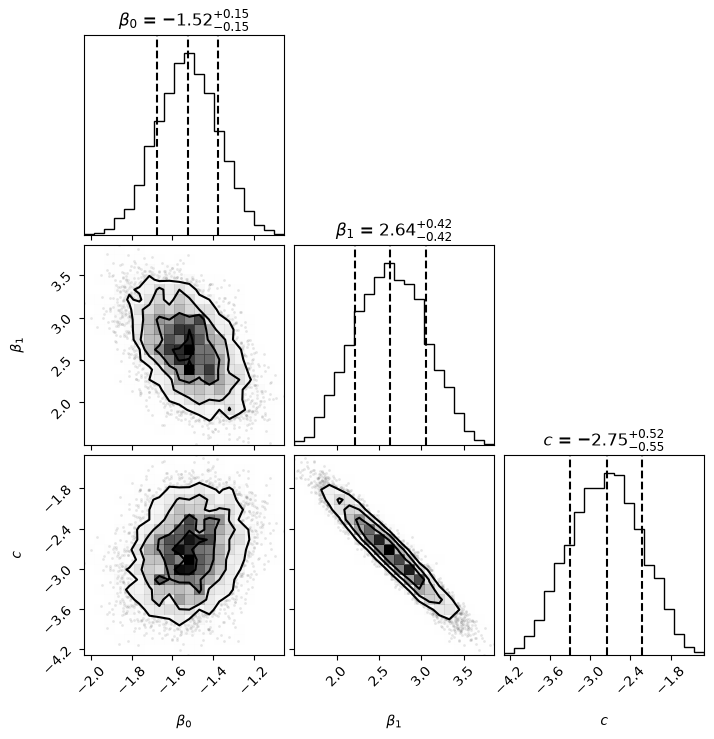

In [5]:
#Perform the same linear regression and bootstrapping for the UCDs with Re and sigma_global
ydata_ucd = UCD_residuals.values
xdata_ucd = np.vstack([np.log10(UCD_df['Re']), np.log10(UCD_df['sigma_global'])]).T

mod = LinearRegression()
mod.fit(xdata_ucd, ydata_ucd)

ini_res = ydata_ucd - mod.predict(xdata_ucd)

boot_list = []
for _ in range(5000):
    bootstrap = ini_res*(2*np.random.randint(2, size = ini_res.size) - 1)
    y_alt = mod.predict(xdata_ucd) + bootstrap

    mod_cycle = LinearRegression().fit(xdata_ucd, y_alt)
    boot_list.append([mod_cycle.coef_[0], mod_cycle.coef_[1], mod_cycle.intercept_])

arr = np.array(boot_list)
corner.corner(arr,
              labels=[r"$\beta_0$",r"$\beta_1$",r"$c$"],
              quantiles=[0.16, 0.5, 0.84],
              show_titles=True,
              title_kwargs={"fontsize": 12})
plt.show()

## UCDVD

Initial fit parameters:
xb = 3.12 +- 0.13
yb = -10.80 +- 0.29
alpha = -2.38 +- 0.06
beta = -1.37 +- 0.13


Percentage of unsuccesfull bootstraps: 13.0%


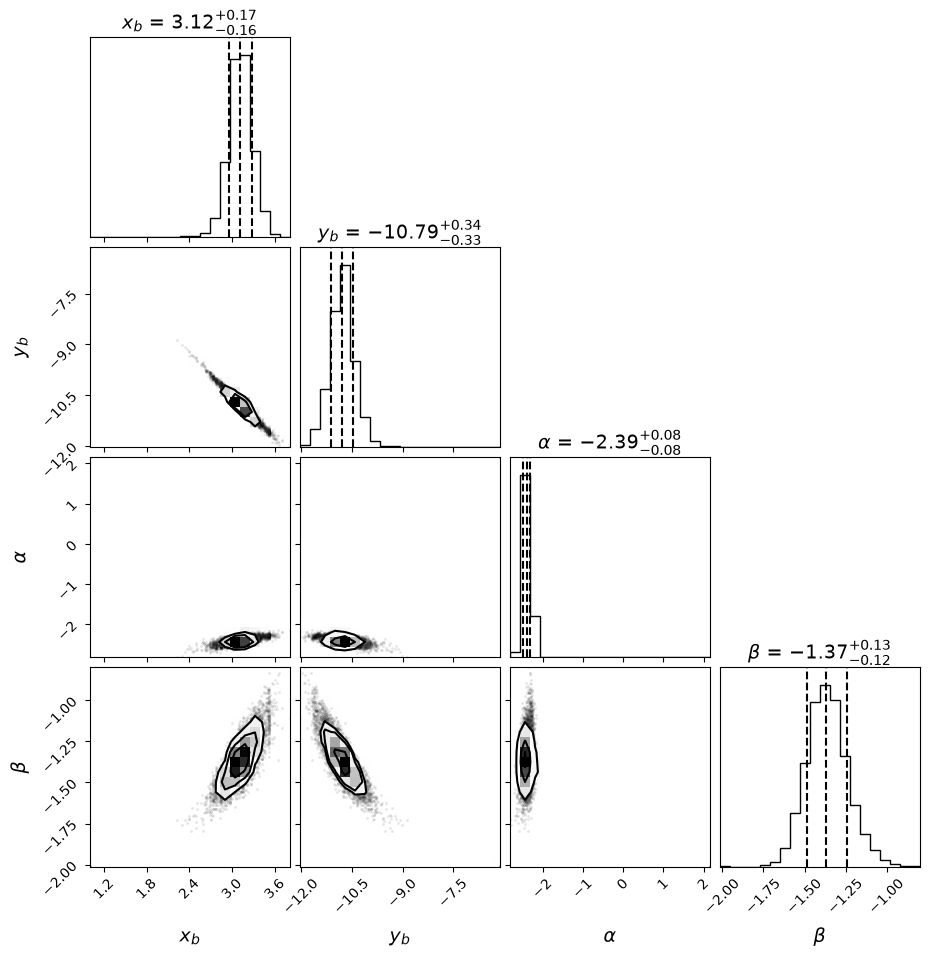

In [6]:
#Define the bilinear relation to fit
def piecewise_linear(x, x0, y0, k1, k2):
    return np.piecewise(x, [x < x0], [lambda x:k1*x + y0-k1*x0, lambda x:k2*x + y0-k2*x0])

#Bring all the data together and fit
x = np.concatenate([np.log10(mw_df['sigma_global']**2 * mw_df['Re']),
                    np.log10(M31_df['sigma_global'].astype(float)**2 * M31_df['Re'].astype(float)), 
                    np.log10(UCD_df['sigma_global']**2 * UCD_df['Re'])
                   ])

y = np.concatenate([mw_df['MV'],M31_df['MV'].astype(float), UCD_df['VMAG']])


p , e = optimize.curve_fit(piecewise_linear, x, y, p0 = [2.5,-10,-2.5,-1.6]) #Provided some initial parameters based on visual inspection of the data in this plane
print(f"Initial fit parameters:")
for i,j,k in zip([r"xb", r"yb", r"alpha", r"beta"], p, np.sqrt(np.diag(e))):
    print(f"{i} = {j:.2f} +- {k:.2f}")
res = y - piecewise_linear(x, *p)

#(Wild) bootstrap; # = 7500
alt_list = []
N = 0
m = 7500
for _ in range(m):
    bootstrap = res*(2*np.random.randint(2, size=res.size) - 1)
    y_alt = piecewise_linear(x,*p) + bootstrap

    try:
        p_alt , e_alt = optimize.curve_fit(piecewise_linear, x, y_alt)
        if (p_alt[0] >= 1) & (p_alt[0] <= 5) & (p_alt[1] >= -13) & (p_alt[1] <= -6): #Remove all realizations that are unreasonable
            alt_list.append(p_alt)
        else:
            N += 1
    except optimize.OptimizeWarning:
        N += 1
        
print(f'Percentage of unsuccesfull bootstraps: {N/m * 100:.1f}%')

arr = np.array(alt_list)
p_avg = np.median(arr, axis = 0)

#Plot the resulting distributions
corner.corner(arr,
              labels=[r"$x_b$", r"$y_b$", r"$\alpha$", r"$\beta$"],
              quantiles=[0.16, 0.5, 0.84],
              show_titles=True,
              title_kwargs={"fontsize": 14},
            label_kwargs={"fontsize": 14})
plt.show()

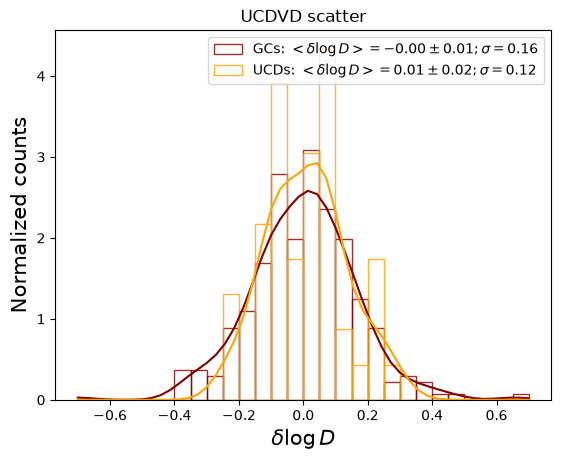

In [7]:
#Extract parameters and define the rewritten bilinear relation for distance estimation
alpha0 = p_avg[2]
beta0 = p_avg[3]
alpha1 = p_avg[1] - alpha0*p_avg[0]
beta1 = p_avg[1] - beta0*p_avg[0]
break_value = 5*(p_avg[0]-1)+p_avg[1]

def logD_prediction(mV, re, sigma):
    if mV + 5*np.log10(sigma**2 * re) < break_value:
        return (mV - alpha0*np.log10(sigma**2 * re) - alpha1 + 5) / (alpha0 + 5)

    if mV + 5*np.log10(sigma**2 * re) >= break_value:
        return (mV - beta0*np.log10(sigma**2 * re) - beta1 + 5) / (beta0 + 5)

logD = np.log10(100e3) #An arbitrarily chosen distance to uniformly shift the UCDs as the input requires 'apparent' values while the UCDs are only given in 'physical' values
UCD_mv = UCD_df['VMAG'] + 5*logD - 5
UCD_re = UCD_df['Re']/ 10**logD

temp_df = M31_df.dropna() #Clean the M31 catalogue of any entry that does not have the entire set of information avialable
alt_logD_pred = np.array([logD_prediction(mv, re, sig) for mv,re,sig in zip(UCD_mv, UCD_re, UCD_df['sigma_global'])])
M31_logD_pred = np.array([logD_prediction(mv, re, sig) for mv,re,sig in zip(temp_df['mV0'].values, temp_df['re']*u.arcsec.to(u.radian), temp_df['sigma_global'].values)])
logD_pred = np.array([logD_prediction(mv, re, sig) for mv,re,sig in zip(mw_df['mV0'], mw_df['re']*u.arcsec.to(u.radian), mw_df['sigma_global'])])

#Plot the distribution of errors on predicted distance
al = .8
bin_width = 0.05
scatter_range = np.linspace(-0.7,0.7,50)
scatter_bins = np.arange(scatter_range.min(),scatter_range.max() + bin_width,bin_width)

gc_scatter = np.concatenate([np.log10(mw_df['D']*1000)-logD_pred,np.log10(780e3)-M31_logD_pred])
plt.hist(gc_scatter, facecolor = 'none', edgecolor = 'maroon', bins = scatter_bins,
         density = True, alpha = al, label = r'GCs: $<\delta\log D> = %.2f\pm%.2f; \sigma = %.2f$' % (gc_scatter.mean(), gc_scatter.std()/np.sqrt(len(gc_scatter)), gc_scatter.std()))
gc_kde = gaussian_kde(gc_scatter)
plt.plot(scatter_range, gc_kde(scatter_range), c = 'maroon')

UCD_scatter = (logD - alt_logD_pred)
plt.hist(UCD_scatter, facecolor = 'none', edgecolor = 'orange', bins = scatter_bins,
         density = True, alpha = al, label = r'UCDs: $<\delta\log D> = %.2f\pm%.2f; \sigma = %.2f$' % (UCD_scatter.mean(), UCD_scatter.std()/np.sqrt(len(UCD_scatter)), UCD_scatter.std()))
ucd_kde = gaussian_kde(UCD_scatter)
plt.plot(scatter_range, ucd_kde(scatter_range), c = 'orange')

plt.legend()
plt.xlabel(r'$\delta\log D$', fontsize = 15)
plt.ylabel('Normalized counts', fontsize = 15)
plt.title('UCDVD scatter')
plt.show()

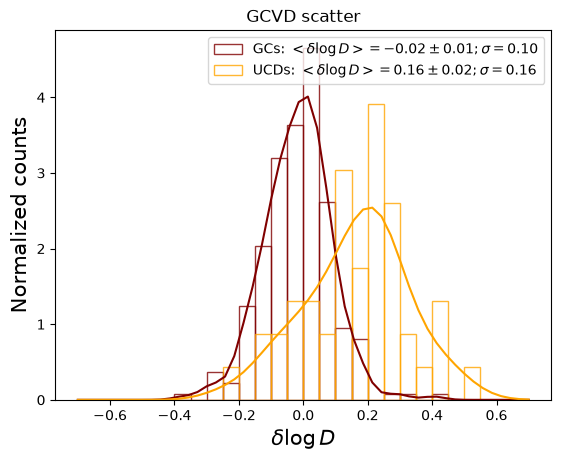

In [8]:
#Translate the GCVD residuals from mag to logD
MW_logD_residuals = -1*(mw_df['MV'] - (-4.49 - 4.73*np.log10(mw_df['sigma_global'])))/5
M31_logD_residuals = -1*(M31_df['MV'] - (-4.49 - 4.73*np.log10(M31_df['sigma_global'])))/5
UCD_logD_residuals = -1*(UCD_df['VMAG'] - (-4.49 - 4.73*np.log10(UCD_df['sigma_global'])))/5

#Plot the distribution of errors on predicted distance
al = .8
bin_width = 0.05
scatter_range = np.linspace(-0.7,0.7,50)
scatter_bins = np.arange(scatter_range.min(),scatter_range.max() + bin_width,bin_width)

gcvd_gc_scatter = np.concatenate([MW_logD_residuals,M31_logD_residuals])
plt.hist(gcvd_gc_scatter, facecolor = 'none', edgecolor = 'maroon', bins = scatter_bins, 
         density = True, alpha = al, label = r'GCs: $<\delta\log D> = %.2f\pm%.2f; \sigma = %.2f$' % (gcvd_gc_scatter.mean(), gcvd_gc_scatter.std()/np.sqrt(len(gcvd_gc_scatter)), gcvd_gc_scatter.std()))
gc_kde = gaussian_kde(gcvd_gc_scatter)
plt.plot(scatter_range, gc_kde(scatter_range), c = 'maroon')

plt.hist(UCD_logD_residuals, facecolor = 'none', edgecolor = 'orange', bins = scatter_bins, 
         density = True, alpha = al, label = r'UCDs: $<\delta\log D> = %.2f\pm%.2f; \sigma = %.2f$' % (UCD_logD_residuals.mean(), UCD_logD_residuals.std()/np.sqrt(len(UCD_logD_residuals)), UCD_logD_residuals.std()))
ucd_kde = gaussian_kde(UCD_logD_residuals)
plt.plot(scatter_range, ucd_kde(scatter_range), c = 'orange')

plt.legend()
plt.xlabel(r'$\delta\log D$', fontsize = 15)
plt.ylabel('Normalized counts', fontsize = 15)
plt.title('GCVD scatter')
plt.show()

## Figure 2

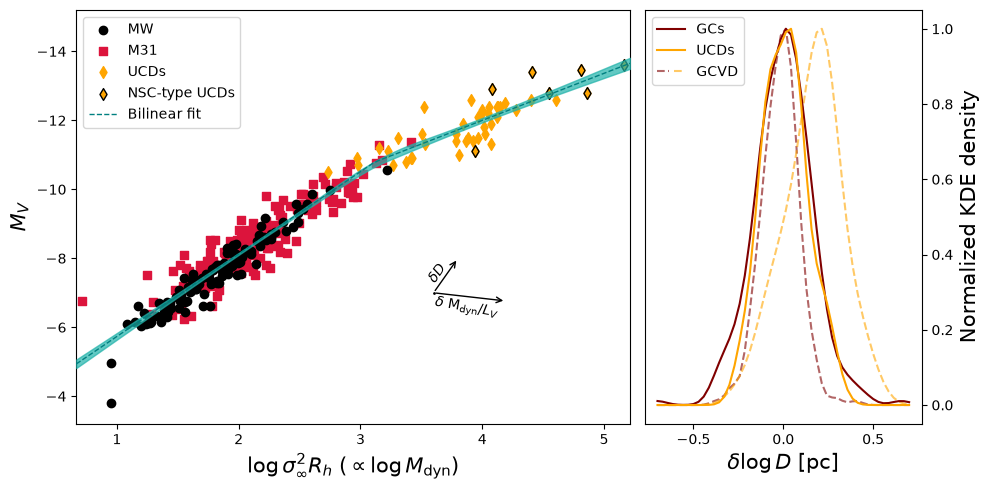

In [9]:
fig, ax = plt.subplots(1,2,figsize = (10,5), width_ratios = [2,1])

ax[0].scatter(np.log10(mw_df['sigma_global']**2 * mw_df['Re']), mw_df['MV'], c = 'black', alpha = 1, label = 'MW', zorder = 2)
ax[0].set_xlabel(r'$\log\sigma_\infty^2 R_{h}$ $(\propto \log M_\mathrm{dyn})$', fontsize = 15)
ax[0].set_ylabel('$M_V$', fontsize = 15)
ax[0].invert_yaxis()

ax[0].scatter(np.log10(M31_df['sigma_global'].astype(float)**2 * M31_df['Re'].astype(float)), M31_df['MV'].astype(float), 
           c = 'crimson', alpha = 1, marker = 's', zorder = 1, label = 'M31')

ax[0].scatter(np.log10(UCD_df['sigma_global']**2 * UCD_df['Re']), UCD_df['VMAG'], c = 'orange', marker = 'd', label = 'UCDs', zorder = 1)
ax[0].scatter(np.log10(UCD_df_NSC['sigma_global']**2 * UCD_df_NSC['Re']), UCD_df_NSC['VMAG'], c = 'orange', marker = 'd', 
           edgecolor = 'black', label = 'NSC-type UCDs', zorder = 2)


x = np.concatenate([np.log10(mw_df['sigma_global']**2 * mw_df['Re']),
                    np.log10(temp_df['sigma_global'].astype(float)**2 * temp_df['Re'].astype(float)), 
                    np.log10(UCD_df['sigma_global']**2 * UCD_df['Re'])])
x_range = np.linspace(x.min()-0.05, x.max()+0.05, 100)

#Find and plot the 16-84th curves from the bootstrap realizations
lines_arr = np.array([piecewise_linear(x_range, *p_boot) for p_boot in arr])
lower_bound_curve = np.array([np.percentile(l, 16, axis = 0) for l in lines_arr.T])
upper_bound_curve = np.array([np.percentile(l, 84, axis = 0) for l in lines_arr.T])

ax[0].fill_between(x_range, lower_bound_curve, upper_bound_curve, color = 'lightseagreen', zorder = 3, alpha = 0.7)
ax[0].plot(x_range, piecewise_linear(x_range, *p_avg),
       c = 'teal', linestyle = 'dashed', label = 'Bilinear fit', zorder = 4, linewidth = 1)

#Setup the arrows for shifts in distance and mass-to-light ratios
x0, y0 = 3.6, -7
dd = 0.2
ax[0].annotate('', xytext = (x0,y0), xy = (x0+dd,y0-5*dd), arrowprops=dict(arrowstyle="->"))
ax[0].text(x = x0-0.06, y = y0 - .3, s = r'$\delta D$', rotation = np.degrees(np.arccos(-1/5))/2 + 4, fontsize = 10)

dmlr = .5
f = (-2.5 / ((-2.5**2) + 1))
ax[0].annotate('', xytext = (x0,y0), xy = (x0 + f*2.5*dmlr, y0 - (f/-2.5)*2.5*dmlr), arrowprops=dict(arrowstyle='->'))
ax[0].text(x = x0, y = y0 + 0.7, s = r'$\delta$ M$_{\rm dyn}/L_V$', rotation = -10)
ax[0].plot(x0,y0, c = 'black', marker = '8', markersize = 1)

ax[0].legend(loc = 'upper left')
ax[0].set_xlim(x.min()-0.05,x.max()+0.05)
ax[0].set_ylim(-3.2,-15.2)

#-----------------------------------------------

#Plot the KDEs of the residuals for the GCs and UCDs for both relations
gc_scatter_UCDVD = np.concatenate([np.log10(mw_df['D']*1000)-logD_pred,np.log10(780e3)-M31_logD_pred])
gc_UCDVD_kde = gaussian_kde(gc_scatter_UCDVD)
kde_gc, = ax[1].plot(scatter_range, gc_UCDVD_kde(scatter_range)/gc_UCDVD_kde(scatter_range).max(), c = 'maroon', zorder = 1)

ucd_kde = gaussian_kde(logD - alt_logD_pred)
kde_ucd, = ax[1].plot(scatter_range, ucd_kde(scatter_range)/ucd_kde(scatter_range).max(), c = 'orange', zorder = 1)

gc_scatter = np.concatenate([MW_logD_residuals,M31_logD_residuals])
gc_kde = gaussian_kde(gc_scatter)
GCVD_kde_gc, = ax[1].plot(scatter_range, gc_kde(scatter_range)/gc_kde(scatter_range).max(), c = 'maroon', linestyle = 'dashed', zorder = 0, alpha = 0.6)

ucd_kde = gaussian_kde(UCD_logD_residuals)
GCVD_kde_ucd, = ax[1].plot(scatter_range, ucd_kde(scatter_range)/ucd_kde(scatter_range).max(), c = 'orange', linestyle = 'dashed', zorder = 0, alpha = 0.6)

handle_pair = (GCVD_kde_gc, GCVD_kde_ucd)
ax[1].legend(handles = [kde_gc, kde_ucd, handle_pair], labels = ['GCs','UCDs','GCVD'], loc = 'upper left',
          handler_map={handle_pair: HandlerTuple(ndivide=None)}) #Plot the GCVD dashed lines in the legend together to not clog up the plot

ax[1].yaxis.tick_right()
ax[1].set_xlabel(r'$\delta\log D$ [pc]', fontsize = 15)
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel('Normalized KDE density', fontsize = 15)
fig.tight_layout()
plt.show()

## DF2 Distance

In [10]:
#Redefine the rewritten bilinear equation to accept any bootstrap realization
def logD_prediction(p, mv, x):
    break_value = 5*(p[0]-1)+p[1]

    if mv + 5*x < break_value:
        intercept = p[1] - p[2]*p[0]
        D = ((mv + 5) - (p[2]*x) - intercept) / (p[2] + 5)
        return  D
        
    elif mv + 5*x >= break_value:
        intercept = p[1] - p[3]*p[0]
        D = ((mv + 5) - (p[3]*x) - intercept) / (p[3] + 5)
    
        return D

    else:
        return 0

#Function to bootstrap the datapoints under their own error assuming the error is Gaussian
def bootstrap_logD_prediction(p, y, x, y_err, x_err, N = 500):
    stor_list = []
    for _ in range(N):
        x_boot, y_boot = np.random.normal(loc = x, scale = x_err), np.random.normal(loc = y, scale = y_err) 
        stor_list.append(logD_prediction(p, y_boot, x_boot))
    return np.array(stor_list)

#Ease-of-use function to accept all bootstrap realizations and apply error bootstrapping for the data
def fit_uncertainty_bootstrap(p_boot, y, x, y_err, x_err):
    stor_list = []
    for p in p_boot[:]:
        stor_list.append(bootstrap_logD_prediction(p, y, x, y_err, x_err))
    return np.array(stor_list)

### Beasley et al. (2025)

In [11]:
#Define the basic properties of the clusters in question (Table 1 from Beasley+25)
name = np.array(['GC39','GC73','GC77','GC85','GC92'])
sig_gl = np.array([6.1,10.3,9.7,7.6,7.1]) #Gaia-ESO
mV = np.array([22.37,21.53,22.10,22.37,22.13]) + 0.14 #Conversion to V from F606W (AB) & Extinction-corrected
rhl = np.array([0.056,0.039,0.086,0.032,0.027]) #arcsec
sig_gl_err = np.array([2.3,1.7,2,1.4,1.8])
mV_err = np.array([0.02,0.02,0.02,0.02,0.02])
rhl_err = np.array([0.004,0.002,0.003,0.002,0.001])

#Work everything into a DataFrame for working
DF2_df = pd.DataFrame(data = np.vstack([name, sig_gl, mV, rhl]).T, columns = ['Name','sigma_global','mV','rhl'])
DF2_df['er_sigma_global'] = sig_gl_err
DF2_df['er_mV'] = mV_err
DF2_df['er_rhl'] = rhl_err

ydata = DF2_df['mV'].values.astype(float)
xdata = np.log10(DF2_df['sigma_global'].astype(float)**2 * DF2_df['rhl'].astype(float)*u.arcsec.to(u.radian))
x_err = np.sqrt( (2/np.log(10))**2 * (DF2_df['er_sigma_global'].astype(float)/DF2_df['sigma_global'].astype(float))**2 
                + (1/np.log(10))**2 * (DF2_df['er_rhl'].astype(float)/DF2_df['rhl'].astype(float))**2  )
y_err = DF2_df['er_mV'].astype(float).values

#Perform bootstrapping with all bootstrap realizations
total_boot_D = np.array([fit_uncertainty_bootstrap(arr, y, x, er_y, er_x) for x,y,er_y,er_x in zip(xdata,ydata,y_err,x_err)])

#Calculate the individual mean logD
means, var = np.array([np.mean(b.ravel()) for b in total_boot_D]), np.array([np.var(b.ravel()) + ucert**2 for ucert,b in zip([0.16,0.12,0.16,0.16,0.16],total_boot_D)])
for i,j,k in zip(name, means, np.sqrt(var)):
    print(f'{i}: logD = {j:.3f} +- {k:.3f}; D = {10**(j-6):.2f} Mpc')

#Weighted mean for the DF2 distance
weights = 1/var
res = np.average(means, weights = weights)
uncert = 1/np.sqrt(np.sum(weights))
print(f'DF2 logD = {res:.2f} +- {uncert:.2f}; D = {10**(res-6):.2f} Mpc')

GC39: logD = 7.240 +- 0.328; D = 17.38 Mpc
GC73: logD = 7.198 +- 0.178; D = 15.79 Mpc
GC77: logD = 7.614 +- 0.192; D = 41.12 Mpc
GC85: logD = 7.200 +- 0.219; D = 15.87 Mpc
GC92: logD = 6.987 +- 0.259; D = 9.70 Mpc
DF2 logD = 7.28 +- 0.10; D = 19.08 Mpc


In [12]:
#Excluding GC77
res = np.average(means[[0,1,3,4]], weights = weights[[0,1,3,4]])
uncert = 1/np.sqrt(np.sum(weights[[0,1,3,4]]))
print(f'DF2 logD = {res:.2f} +- {uncert:.2f}; D = {10**(res-6):.2f} Mpc')

DF2 logD = 7.16 +- 0.11; D = 14.54 Mpc


### Figure 3

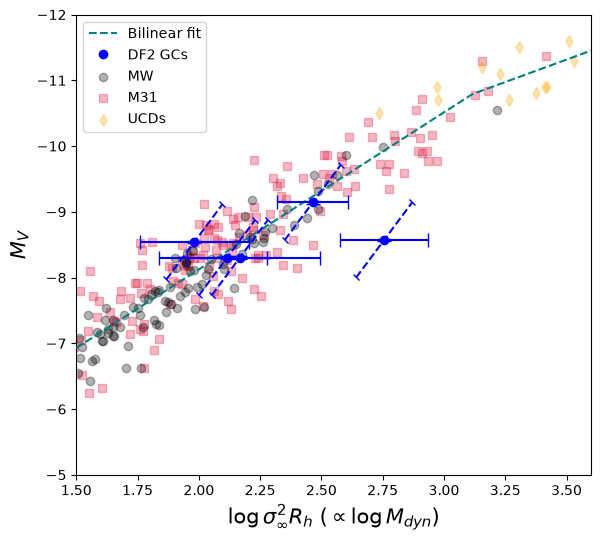

In [13]:
#Define the rotation for the distance error bars
rotation_transform = Affine2D().rotate_deg(np.degrees(np.arccos(-1/5))/2 -3)
rotated_marker = MarkerStyle(marker='|', transform=rotation_transform)

figsize =  fig_size(480, ratio = .9)
scale = figsize[0] / (480.0 / 72.27) 
fig, ax = plt.subplots(figsize = figsize)

#Plot the bilinear fit for a visual guide
x_range = np.linspace(1.5, 3.6, 100)
ax.plot(x_range, piecewise_linear(x_range, *p_avg),
       c = 'teal', linestyle = 'dashed', label = 'Bilinear fit', zorder = 3)

#Plot the DF2 data at the found distance
ax.plot(xdata + res, ydata - 5*res + 5, color = 'blue', marker = 'o', linestyle = ' ', zorder = 4, label = 'DF2 GCs')
ax.errorbar(xdata + res, ydata - 5*res + 5, xerr = x_err, yerr = y_err, color = 'blue', zorder = 3, capsize = 5, linestyle = ' ')
for x,y in zip(xdata,ydata): #Plot the point of 1 sigma out to make the error bars
    ax.plot([x + (res - uncert), x+ (res + uncert)], 
            [y - 5*(res - uncert) + 5, y - 5*(res + uncert) + 5], linestyle = '--', color = 'blue', marker = rotated_marker, zorder = 4)
ax.set_xlabel(r'$\log\sigma_\infty^2 R_{h}$ $(\propto \log M_{dyn})$', fontsize = 15)
ax.set_ylabel(r'$M_V$', fontsize = 15)
ax.invert_yaxis()
ax.set_xlim(1.5,3.6)
ax.set_ylim(-5,-12)

#Plot the MW+M31+UCD for further visual guide
ax.scatter(np.log10(mw_df['sigma_global']**2 * mw_df['Re']), mw_df['MV'], c = 'black', label = 'MW', zorder = 2, alpha = 0.3)
ax.scatter(np.log10(temp_df['sigma_global'].astype(float)**2 * temp_df['Re'].astype(float)), temp_df['MV'].astype(float), 
           c = 'crimson', marker = 's', zorder = 1, label = 'M31', alpha = 0.3)
ax.scatter(np.log10(UCD_df['sigma_global']**2 * UCD_df['Re']), UCD_df['VMAG'], c = 'orange', marker = 'd', label = 'UCDs', zorder = 1, alpha = 0.3)

ax.legend()
plt.show()

### Van Dokkum et al. (2018)

In [14]:
name = np.array(['GC39','GC73','GC77','GC85','GC92'])
sig_gl = np.array([6.1,10.3,9.7,7.6,7.1]) #Gaia-ESO
mV = np.array([22.2,21.4,21.9,22.3,22.1]) + 0.14
rhl = np.array([0.081,0.069,0.102,0.056,0.046]) #arcsec
sig_gl_err = np.array([2.3,1.7,2,1.4,1.8])
mV_err = np.array([0.05,0.05,0.05,0.05,0.05])
rhl_err = np.array([0.007,0.007,0.006,0.008,0.01])

DF2_df = pd.DataFrame(data = np.vstack([name, sig_gl, mV, rhl]).T, columns = ['Name','sigma_global','mV','rhl'])
DF2_df['er_sigma_global'] = sig_gl_err
DF2_df['er_mV'] = mV_err
DF2_df['er_rhl'] = rhl_err

ydata = DF2_df['mV'].values.astype(float)
xdata = np.log10(DF2_df['sigma_global'].astype(float)**2 * DF2_df['rhl'].astype(float)*u.arcsec.to(u.radian))
x_err = np.sqrt( (2/np.log(10))**2 * (DF2_df['er_sigma_global'].astype(float)/DF2_df['sigma_global'].astype(float))**2 
                + (1/np.log(10))**2 * (DF2_df['er_rhl'].astype(float)/DF2_df['rhl'].astype(float))**2  )
y_err = DF2_df['er_mV'].astype(float).values

total_boot_D = np.array([fit_uncertainty_bootstrap(arr, y, x, er_y, er_x) for x,y,er_y,er_x in zip(xdata,ydata,y_err,x_err)])

means, var = np.array([np.mean(b.ravel()) for b in total_boot_D]), np.array([np.var(b.ravel()) + ucert**2 for ucert,b in zip([0.16,0.12,0.16,0.16,0.16],total_boot_D)])
for i,j,k in zip(name, means, np.sqrt(var)):
    print(f'{i}: logD = {j:.3f} +- {k:.3f}; D = {10**(j-6):.2f} Mpc')

weights = 1/var
res = np.average(means, weights = weights)
uncert = 1/np.sqrt(np.sum(weights))

print(f'DF2 logD = {res:.2f} +- {uncert:.2f}; D = {10**(res-6):.2f} Mpc')

GC39: logD = 7.313 +- 0.318; D = 20.56 Mpc
GC73: logD = 7.359 +- 0.169; D = 22.86 Mpc
GC77: logD = 7.592 +- 0.190; D = 39.10 Mpc
GC85: logD = 7.393 +- 0.221; D = 24.69 Mpc
GC92: logD = 7.185 +- 0.269; D = 15.31 Mpc
DF2 logD = 7.40 +- 0.10; D = 25.07 Mpc


### Trujillo et al. (2019)

In [15]:
name = np.array(['GC39','GC73','GC77','GC85','GC92'])
sig_gl = np.array([6.1,10.3,9.7,7.6,7.1]) #Gaia-ESO
mV = np.array([22.38,21.52,22.03,22.41,22.39]) + 0.116
rhl = np.array([0.083,0.077,0.118,0.060,0.055])
sig_gl_err = np.array([2.3,1.7,2,1.4,1.8])
mV_err = np.array([0.05,0.05,0.05,0.05,0.05])
rhl_err = np.array([0.02,0.02,0.02,0.02,0.02])

DF2_df = pd.DataFrame(data = np.vstack([name, sig_gl, mV, rhl]).T, columns = ['Name','sigma_global','mV','rhl'])
DF2_df['er_sigma_global'] = sig_gl_err
DF2_df['er_mV'] = mV_err
DF2_df['er_rhl'] = rhl_err

ydata = DF2_df['mV'].values.astype(float)
xdata = np.log10(DF2_df['sigma_global'].astype(float)**2 * DF2_df['rhl'].astype(float)*u.arcsec.to(u.radian))
x_err = np.sqrt( (2/np.log(10))**2 * (DF2_df['er_sigma_global'].astype(float)/DF2_df['sigma_global'].astype(float))**2 
                + (1/np.log(10))**2 * (DF2_df['er_rhl'].astype(float)/DF2_df['rhl'].astype(float))**2  )
y_err = DF2_df['er_mV'].astype(float).values

total_boot_D = np.array([fit_uncertainty_bootstrap(arr, y, x, er_y, er_x) for x,y,er_y,er_x in zip(xdata,ydata,y_err,x_err)])
means, var = np.array([np.mean(b.ravel()) for b in total_boot_D]), np.array([np.var(b.ravel()) + ucert**2 for ucert,b in zip([0.16,0.12,0.16,0.16,0.16],total_boot_D)])
for i,j,k in zip(name, means, np.sqrt(var)):
    print(f'{i}: logD = {j:.3f} +- {k:.3f}; D = {10**(j-6):.2f} Mpc')

weights = 1/var
res = np.average(means, weights = weights)
uncert = 1/np.sqrt(np.sum(weights))

print(f'DF2 logD = {res:.2f} +- {uncert:.2f}; D = {10**(res-6):.2f} Mpc')

GC39: logD = 7.376 +- 0.322; D = 23.76 Mpc
GC73: logD = 7.421 +- 0.177; D = 26.34 Mpc
GC77: logD = 7.654 +- 0.187; D = 45.06 Mpc
GC85: logD = 7.446 +- 0.242; D = 27.90 Mpc
GC92: logD = 7.351 +- 0.282; D = 22.42 Mpc
DF2 logD = 7.48 +- 0.10; D = 30.08 Mpc
